### SIMPLE MULTI AI AGENT ARCHITECURE

In [1]:
import os 
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver

C:\Users\PMLS\AppData\Local\Temp\ipykernel_17140\3004209236.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")

In [3]:
## defining state, state will have all the information which will be flowing from graph
class AgentState(MessagesState):
    next_agent:str # which agent should go next

In [4]:
# create simple tools for multi ai agent

@tool
def search_web(query: str) -> str:
    """Search the web for information"""
    # using tavily search
    search = TavilySearchResults(max_results=3)
    results= search.invoke(query)
    return str(results)

@tool
def summary(content: str) -> str:
    """write a summary of provided content"""
    # simple summary generation of the date given by web search agent
    summary= f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [5]:
llm=ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000029D60D00410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029D60E574D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [7]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [8]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

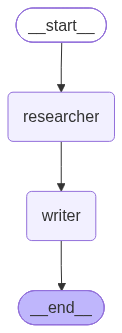

In [9]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [10]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

In [11]:
response["messages"][-1].content
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reasearch about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (fc_f2b7a983-baa9-4b53-b2bc-0837b661e729)
 Call ID: fc_f2b7a983-baa9-4b53-b2bc-0837b661e729
  Args:
    query: agentic AI use cases in business
================================== Ai Message ==================================

**Agentic AI in Business – Key Use‑Case Summary**

| Domain | Typical Agentic AI Role | What It Solves | Example Applications |
|--------|------------------------|----------------|----------------------|
| **Customer Experience** | Conversational agents that autonomously manage complex support flows | Reduces wait times, scales support, improves satisfaction | 24/7 chatbots that triage issues, resolve common queries, and hand off to human agents only when needed |
| **Sales & Lead Generation** | Intelligent sales assistants th